- To run this notebook you need to check out the options_apprailsa
- This notebook does what does simialr to what notebok 1 does but uses the new costbenfit module t prepare for future usage within the BioFincas proect and in UNU
- To not make the notebook so clutery with text we efer to how the expousre , hazard are dervide in notebook 1 
- Before we deine the snapshots, i.e., the exposure, vulnerability and hazard for different sections, we begin by defining these objects
- Here we will work with 3 time frames current, near future and future realted to the pathways you choose to model https://en.wikipedia.org/wiki/Climate_inertia 


Idea
* There is already some shade trees providing cooling this will be the **baseline** hazard
* The measure to compare is if we increase agroforesty what are the benefits?


## Initial parameters

In [1]:
from pathlib import Path
import os

# Define output and input directories
INPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
OUTPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/output")

# Define the hazard type
hazard_type = 'VPD'

# 1 - Making the exposure, hazard and impact function for the snapshots  

## 1.1 - Exposure (for multiple snapshots)

Make the Exposure

In [2]:
from utils_cb import get_crop_prod_exposure, COUNTRY_BOUNDS, FILES_CROP_PROD, FILES_CROP_HARVEST

# Get the exposure object for the given crop and bounding box based on the SPAM crop production data
exp = get_crop_prod_exposure(file = INPUT_DIR / FILES_CROP_PROD["coffee"], # file path to the crop production data
                                             bbox = COUNTRY_BOUNDS['MEX'], # bounding box for the country
                                            harvest_area_file= INPUT_DIR / FILES_CROP_HARVEST["coffee"] # file path to the harvest area data
                                            )

# Print the total production value
print(f"Total production value for coffee in Mexico: {exp.gdf['value'].sum()} tonnes")



Total production value for coffee in Mexico: 800116.625 tonnes


In [3]:
# Lets rescale the production value given the total exported coffe from some source
total_exported_coffee = 167000  # Example value in tonnes
exp.gdf['value'] = exp.gdf['value'] * total_exported_coffee / exp.gdf['value'].sum()

Look at the exposure data. 

As shown the majority of production is concentrated in southern Mexico—particularly.

In [4]:
from tabulate import tabulate

# Print and plot the exposure object
print(tabulate(exp.gdf.head(), headers='keys', tablefmt='psql'))

# Plot the exposure object
# exp.plot_basemap()

+----+----------+---------------------+------------------------------------------------+
|    |    value |   harvest_area (ha) | geometry                                       |
|----+----------+---------------------+------------------------------------------------|
|  0 | 0.020872 |                 1   | POINT (-100.9583333333513 23.87500000001502)   |
|  1 | 0.020872 |                 1   | POINT (-100.87500000001799 23.87500000001502)  |
|  2 | 0.020872 |                 1   | POINT (-100.79166666668468 23.87500000001502)  |
|  3 | 0.125232 |                 5.9 | POINT (-100.9583333333513 23.791666666681706)  |
|  4 | 0.020872 |                 1   | POINT (-100.70833333335136 23.791666666681706) |
+----+----------+---------------------+------------------------------------------------+


Add and replace the site coordinates provided by Christian Bunn

In [5]:
from pathlib import Path
from climada.entity import Exposures
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.spatial import cKDTree
from tabulate import tabulate

# Define input path
file = INPUT_DIR / "CoffeeCAM_anonymized.csv"

if file.exists():
    print(f"📄 File found: {file.name}")

    # Step 1: Load and convert CSV to GeoDataFrame
    df = pd.read_csv(file)
    # Only include the columns Longitude, Latitude
    df = df[['Longitude', 'Latitude']]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]), crs="EPSG:4326")
    gdf = gdf.drop(columns=["Longitude", "Latitude"])
    exp_sites = Exposures(gdf)

    # Step 2: Extract GeoDataFrames
    exp_gdf = exp.gdf.copy()
    new_sites_gdf = exp_sites.gdf.copy()

    # Step 3: Reproject to UTM for distance calculation
    orig_crs = exp_gdf.crs
    exp_gdf = exp_gdf.to_crs(epsg=32614)
    new_sites_gdf = new_sites_gdf.to_crs(exp_gdf.crs)

    # Step 4: Interpolate using inverse distance weighted NN
    tree = cKDTree(np.array([(pt.x, pt.y) for pt in exp_gdf.geometry]))
    tolerance = 2000  # meters
    new_values, new_areas = [], []

    for site_geom in new_sites_gdf.geometry:
        site_coord = np.array([site_geom.x, site_geom.y])
        idxs = tree.query_ball_point(site_coord, r=tolerance)

        if not idxs:
            new_values.append(np.nan)
            new_areas.append(np.nan)
            continue

        neighbors = exp_gdf.iloc[idxs]
        distances = np.array([site_geom.distance(pt) for pt in neighbors.geometry])
        distances[distances == 0] = 1e-6
        weights = 1 / distances
        weights /= weights.sum()

        new_values.append(np.sum(weights * neighbors["value"].values))
        new_areas.append(np.sum(weights * neighbors["harvest_area (ha)"].values))

    new_sites_gdf["value"] = new_values
    new_sites_gdf["harvest_area (ha)"] = new_areas
    new_sites_gdf = new_sites_gdf.dropna(subset=["value", "harvest_area (ha)"])
    new_sites_gdf = new_sites_gdf.to_crs(orig_crs)

    # Step 5: Replace exposure object
    exp_interpolated = Exposures(new_sites_gdf)
    exp_interpolated.value_unit = exp.value_unit
    exp = exp_interpolated  # 👈 replace original exposure

    # Step 6: Display results
    print("✅ Exposure object successfully updated from CoffeeCAM_anonymized.csv")
    print(tabulate(exp.gdf.head(), headers="keys", tablefmt="psql"))
    #exp.plot_basemap()

else:
    print(f"⚠️ File not found: {file}")


📄 File found: CoffeeCAM_anonymized.csv
✅ Exposure object successfully updated from CoffeeCAM_anonymized.csv
+-----+---------+---------------------+-----------------------------------------+
|     |   value |   harvest_area (ha) | geometry                                |
|-----+---------+---------------------+-----------------------------------------|
|  78 | 14.4643 |               955.8 | POINT (-99.04789627 21.47238839)        |
|  82 | 14.4643 |               955.8 | POINT (-99.03123769 21.458290509999998) |
|  84 | 14.4643 |               955.8 | POINT (-99.03515156 21.449611379999997) |
|  85 | 14.4643 |               955.8 | POINT (-99.05082035 21.44880705)        |
| 104 | 77.435  |              1714.6 | POINT (-98.94269195 21.38326803)        |
+-----+---------+---------------------+-----------------------------------------+


### 1.1.2 🌳 Canopy Cover Data

Download the data

In [6]:
from utils_cb import download_if_missing, generate_hansen_tile_urls_from_bounds

# Download Hansen tiles based for Mexico
tile_urls = generate_hansen_tile_urls_from_bounds(
    lat_min=10,
    lat_max=30,
    lon_min=-110,
    lon_max=-90
)    

# Download each tile
dest_folder =  INPUT_DIR / "Hansen_TreeCover"
for fname, url in tile_urls.items():
    print(fname, "→", url)
    download_if_missing(url, dest_folder =  INPUT_DIR / "Hansen_TreeCover"
, filename=fname)

Hansen_GFC-2019-v1.7_treecover2000_10N_110W.tif → https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_10N_110W.tif
✅ File already exists: /Users/viggo/Documents/Programming/Consult/UNU/data/Hansen_TreeCover/Hansen_GFC-2019-v1.7_treecover2000_10N_110W.tif
Hansen_GFC-2019-v1.7_treecover2000_10N_100W.tif → https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_10N_100W.tif
✅ File already exists: /Users/viggo/Documents/Programming/Consult/UNU/data/Hansen_TreeCover/Hansen_GFC-2019-v1.7_treecover2000_10N_100W.tif
Hansen_GFC-2019-v1.7_treecover2000_10N_090W.tif → https://storage.googleapis.com/earthenginepartners-hansen/GFC-2019-v1.7/Hansen_GFC-2019-v1.7_treecover2000_10N_090W.tif
✅ File already exists: /Users/viggo/Documents/Programming/Consult/UNU/data/Hansen_TreeCover/Hansen_GFC-2019-v1.7_treecover2000_10N_090W.tif
Hansen_GFC-2019-v1.7_treecover2000_20N_110W.tif → https://storage.goog

Load the data

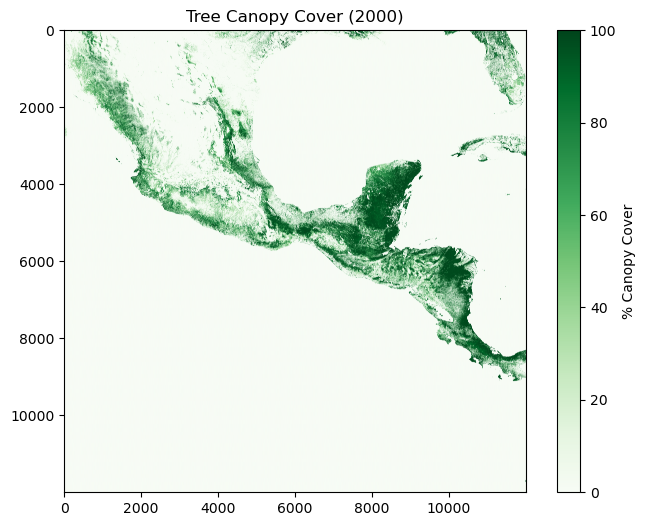

In [7]:
from utils_cb import merge_rasters, downsample_raster, add_canopy_cover_to_exposure
import matplotlib.pyplot as plt

# --- CONFIG ---
canopy_tif_path = INPUT_DIR / "merged_treecover2000.tif" # Path to the canopy raster file

# Load the merged raster file
if not canopy_tif_path.exists():
    print("Merged file not found. Creating...")
    merge_rasters(input_dir = INPUT_DIR / "Hansen_TreeCover", # input directory containing the raster tiles
                 output_path = canopy_tif_path # output path for the merged raster
                    )

# Plot
downsampling_factor = 10  # or None for full resolution for faster plotting
plt.figure(figsize=(8, 6))
plt.imshow(downsample_raster(canopy_tif_path, downsampling_factor), 
           cmap='Greens')
plt.colorbar(label='% Canopy Cover')
title = f"Tree Canopy Cover (2000)"
plt.title(title)
plt.show()

To estimate the canopy cover to each site, we add the average canopy cover by creating a buffer zone aorund the grid-point/site.

In [ ]:
# Add canopy cover to the exposure object
buffer_m = 500  # Buffer in meters for the exposure points
exp = add_canopy_cover_to_exposure(exp, canopy_tif_path, buffer_m)
print(tabulate(exp.gdf[["value", "canopy_cover", "harvest_area (ha)"]].head(), headers='keys', tablefmt='psql'))

+-----+---------+----------------+---------------------+
|     |   value |   canopy_cover |   harvest_area (ha) |
|-----+---------+----------------+---------------------|
|  78 | 14.4643 |        87.1594 |               955.8 |
|  82 | 14.4643 |        87.9772 |               955.8 |
|  84 | 14.4643 |        83.0158 |               955.8 |
|  85 | 14.4643 |        80.2184 |               955.8 |
| 104 | 77.435  |        86.6992 |              1714.6 |
+-----+---------+----------------+---------------------+


Define the exp for near futurure, and future exposure 

- Here one can add a growth parameter of how much thecrop yield changes

In [9]:
import copy

# Define the exposure for near future and future
exp_dict = {'present': exp, # Current exposure
            'near_future': copy.deepcopy(exp), # Placeholder for near future exposure
            'future': copy.deepcopy(exp) # Placeholder for future exposure
  } 

## 1.2 – Hazard 

Download the data 

In [10]:
from utils_cb import download_terraclimate_data

# Download historical TerraClimate data for Mexico
download_terraclimate_data(
    output_dir = INPUT_DIR / "terra_climate",
    country_code="MEX",
    lat_bounds=(32, 13),
    lon_bounds=(-120, -85),
    variables=["tmax", "vpd"], # Variables to download
    years=range(1985, 2023),
    download_type="historical"
)


# Download future scenario data for +2C
download_terraclimate_data(
    output_dir = INPUT_DIR / "terra_climate",
    download_type="scenario",
    scenario="plus2C",
    scenario_prefix="2c",
    country_code="MEX",
    lat_bounds=(32, 13),
    lon_bounds=(-120, -85),
    variables=["tmax", "vpd"],  # Variables to download
    years=range(1985, 2015)
)

# Download future scenario data for +4C
download_terraclimate_data(
    output_dir = INPUT_DIR / "terra_climate",
    download_type="scenario",
    scenario="plus4C",
    scenario_prefix="4c",
    country_code="MEX",
    lat_bounds=(32, 13),
    lon_bounds=(-120, -85),
    variables=["tmax", "vpd"],  # Variables to download
    years=range(1985, 2015)
)

✅ Skipping existing: TerraClimate_tmax_1985_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1986_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1987_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1988_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1989_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1990_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1991_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1992_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1993_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1994_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1995_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1996_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1997_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1998_MEX.nc
✅ Skipping existing: TerraClimate_tmax_1999_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2000_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2001_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2002_MEX.nc
✅ Skipping existing: TerraClimate_tmax_2003_MEX.nc
✅ Skipping existing: TerraClima

Load the raster files to generate present and future hazard

📂 Loading 38 files for variable 'vpd'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
Plotting present hazard intensity for VPD...
📂 Loading 30 files for variable 'vpd'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
Plotting near_future hazard intensity for VPD...
📂 Loading 30 files for variable 'vpd'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
Plotting future ha

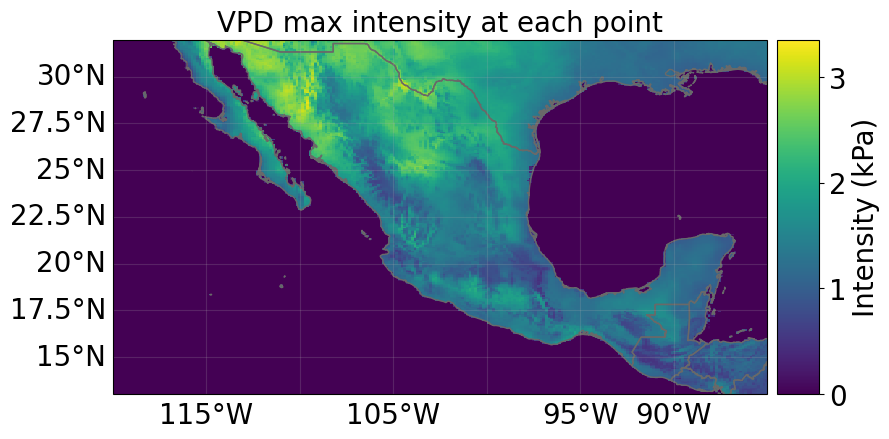

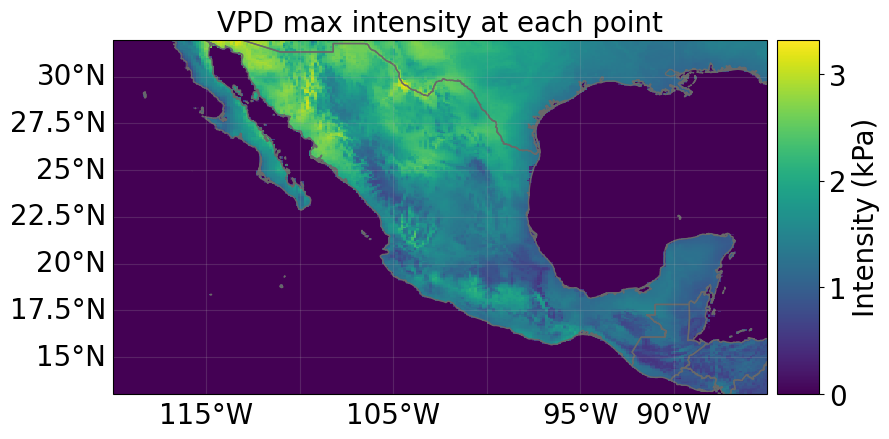

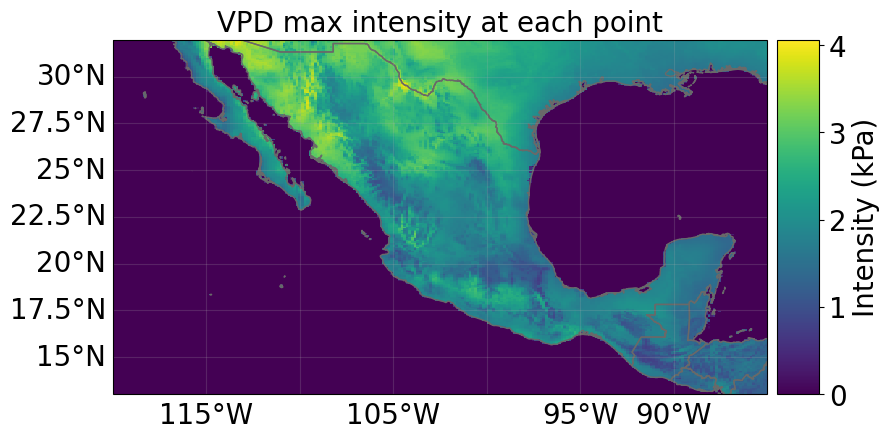

In [11]:
from utils_cb import create_hazard_from_nc_files
from climada.hazard import Hazard

# Determine the corresponding parameters for the hazard type
nc_files = {'present': [], 'near_future': [], 'future': []}
haz_dict = {'present': Hazard, 'near_future': Hazard, 'future': Hazard}

if hazard_type == 'VPD':
    agg = 'mean',
    varname = 'vpd'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_MEX.nc"))
    nc_files['near_future'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_plus2C_vpd_*_MEX.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_plus4C_vpd_*_MEX.nc"))  # Not used in this example
    units = 'kPa'
    months = [5, 6, 7, 8, 9, 10, 11]  # April to November
elif hazard_type == 'Tmax':
    agg = 'max'
    varname = 'tmax'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_MEX.nc"))
    nc_files['near_future'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_plus2C_tmax_*_MEX.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_plus4C_tmax_*_MEX.nc"))
    units = 'C'
    months = [5, 6, 7, 8, 9, 10, 11] # April to November


# Store the hazard type and parameters in a dictionary
for key in nc_files:
    haz_dict[key] = create_hazard_from_nc_files(
                        nc_files[key],
                        varname=varname,
                        haz_type=hazard_type,
                        units=units,
                        agg=agg[0],
                        months=months,
                        nan_replacement=0.0  # Use NaN to keep sparse matrix
                    )
    # Plot the hazard object
    print(f"Plotting {key} hazard intensity for {hazard_type}...")
    haz_dict[key].plot_intensity(0)


### 3.2 Baseline Hazard – Intensity given the canopy level

Since the adaption measure is the change the canopy level at each site in relation to the curret levels. Each site may already be exposed to a different hazard inte


This Reproject the hazard values on the exposure sites and derive a different hazard set given the canopy level.. We do this because the hazard intenity will later on depend on the canopy level at each given site and some sites corresponds to the smae centroid in the hazard file.

Reproject the hazard values on the exposure sites. 

🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for present:
🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for near_future:
🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for future:


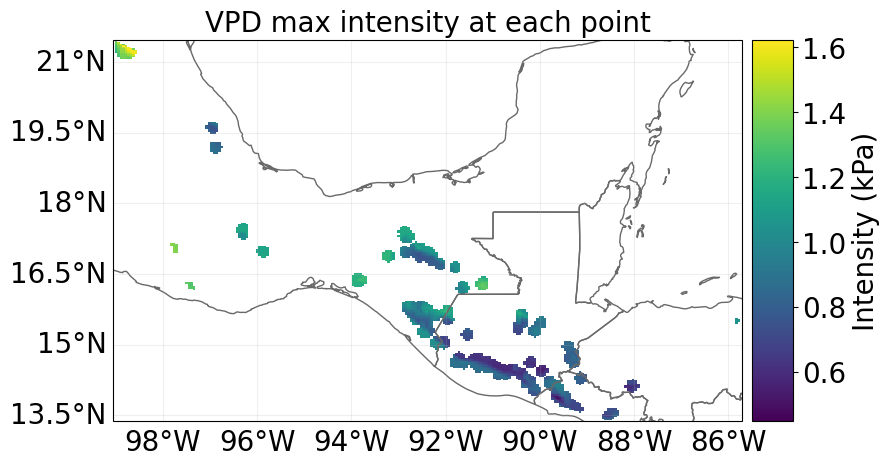

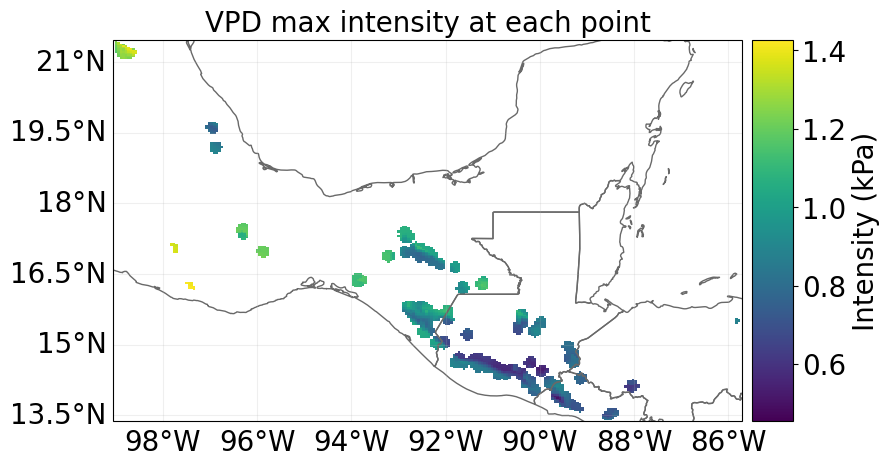

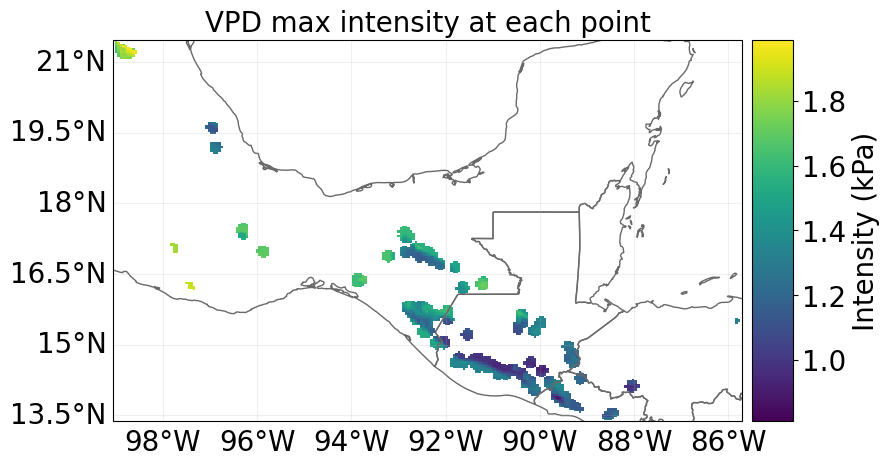

In [12]:
from utils_cb import reproject_hazard_to_exposures

haz_site_dict = {'present': Hazard, 'near_future': Hazard, 'future': Hazard}

for key in haz_dict:
    # Reproject the hazard to the exposure sites
    haz_site_dict[key] = reproject_hazard_to_exposures(haz_dict[key], exp)
    # Plot the site-level hazard
    print(f"Site-level hazard for {key}:")
    haz_site_dict[key].plot_intensity(0)


#### 3.2.1 Baseline Hazard – Adjusted given the Canopy Level

We now make use of the `adjust_hazard_with_exposure_modifier` Define function in tersm of how much the canopy level changes the hazard

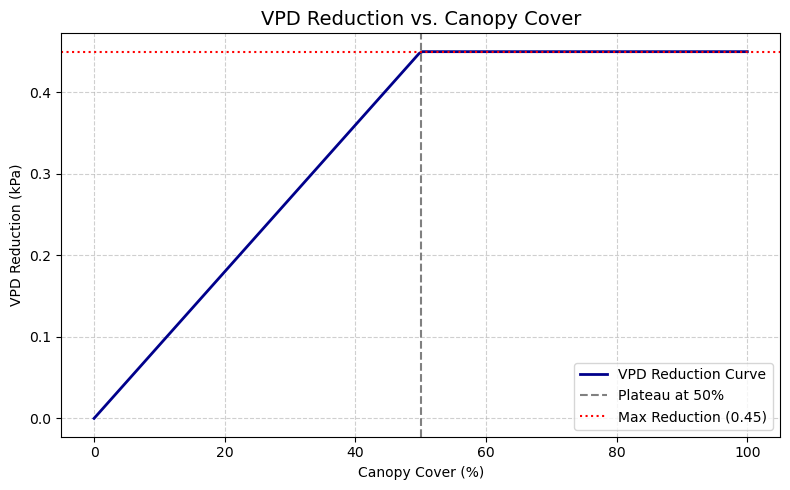

In [30]:
from utils_cb import helper_adj_fcn_canopy_tmax, helper_adj_fcn_canopy_vpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Decide the adjustment function and its parameters
if hazard_type.upper() == 'TMAX':
    adjustment_fn = helper_adj_fcn_canopy_tmax
    adjustment_kwargs = {
        "max_cooling": 2.5,
        "plateau_at": 50
    }
    ylabel = "Temperature Reduction (°C)"
    title = "Tmax Cooling Effect vs. Canopy Cover"
    label = "Cooling Curve"
elif hazard_type.upper() == 'VPD':
    adjustment_fn = helper_adj_fcn_canopy_vpd
    adjustment_kwargs = {
        "max_cooling": 3.0,
        "plateau_at": 50,
        "vpd_sensitivity": 0.15
    }
    ylabel = "VPD Reduction (kPa)"
    title = "VPD Reduction vs. Canopy Cover"
    label = "VPD Reduction Curve"
else:
    raise ValueError(f"Unsupported hazard type: {hazard_type}")


# Inputs
canopy = np.linspace(0, 100, 200)
n_sites = len(canopy)

# Apply adjustment function
reduction = adjustment_fn(
    hazard_matrix=np.zeros((1, n_sites)),  # Dummy input,
    exposure_gdf=pd.DataFrame({'canopy_cover': canopy}),
    **adjustment_kwargs
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, reduction, label=label, linewidth=2, color="darkblue")
plt.axvline(adjustment_kwargs["plateau_at"], color='gray', linestyle='--', label=f'Plateau at {adjustment_kwargs["plateau_at"]}%')
plt.axhline(reduction.max(), color='red', linestyle=':', label=f'Max Reduction ({reduction.max():.2f})')

plt.title(title, fontsize=14)
plt.xlabel("Canopy Cover (%)")
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


This function will be used to change the hazard intensity given the canopy level

<GeoAxes: title={'center': 'VPD max intensity at each point'}>

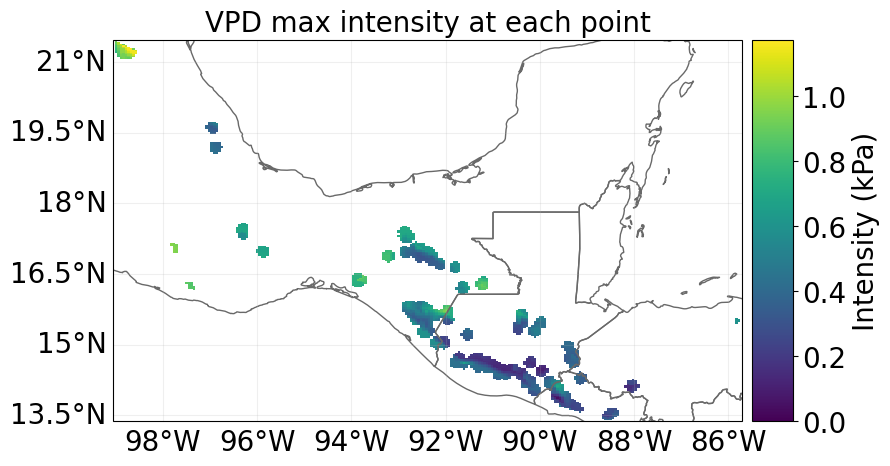

In [ ]:
from utils_cb import apply_canopy_scenario, adjust_hazard_with_exposure_modifier

# Apply the adjustment function to the hazard object
exp_col = apply_canopy_scenario(exp, canopy_scenario="current") # or use a specific canopy cover value, e.g. 50
haz_site_adjusted = adjust_hazard_with_exposure_modifier(
    exposure=exp_col,
    hazard = haz_site_dict['present'],
    adjustment_fn = adjustment_fn,
    adjustment_kwargs=adjustment_kwargs
)

# Plot intensity of first event/year
haz_site_adjusted.plot_intensity(0)

Now do it for all the exposures

In [31]:
haz_adjusted_dict = {'present': haz_site_adjusted}  # Store the adjusted hazard

# Store the adjusted hazard for near future and future scenarios
haz_adjusted_dict['near_future'] = adjust_hazard_with_exposure_modifier(
    exposure=exp_dict['near_future'],
    hazard=haz_site_dict['near_future'],
    adjustment_fn=adjustment_fn,
    adjustment_kwargs=adjustment_kwargs
)
haz_adjusted_dict['future'] = adjust_hazard_with_exposure_modifier(
    exposure=exp_dict['future'],
    hazard=haz_site_dict['future'],
    adjustment_fn=adjustment_fn,
    adjustment_kwargs=adjustment_kwargs
)

## 1.3 – Impact function (Vulnerability)

As mentioned in Step 3, the vulnerability curve is sourced from the following study: [Kath et al. (2022), *Nature Food*](https://www.nature.com/articles/s43016-022-00614-8)


<Axes: title={'center': 'VPD 1: VPD Empirical Yield Loss'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

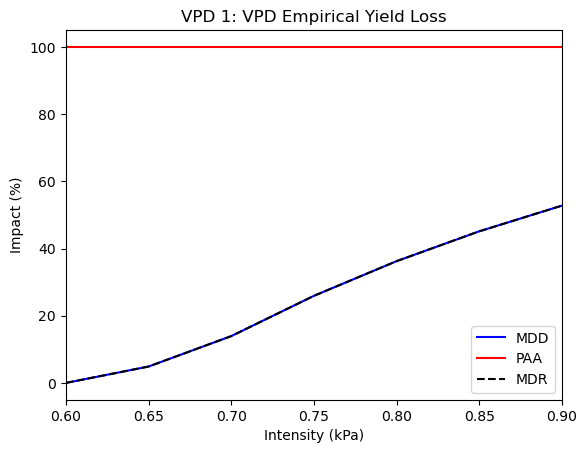

In [72]:
from utils_cb import impact_func_from_kath

hazard_type = 'VPD'

if hazard_type.upper() == 'TMAX':
    impf = impact_func_from_kath(
        file_path= "tasmax_effect_approximation.csv",
        intensity_col="Mean_Tasmax_C",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="Tmax",
        unit="°C",
        name="Tmax Empirical Yield Loss"
    )
elif hazard_type.upper() == 'VPD':
    impf = impact_func_from_kath(
        file_path= "vpd_effect_approximation.csv",
        intensity_col="Mean_VPD_kPa",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="VPD",
        unit="kPa",
        name="VPD Empirical Yield Loss"
    )

impf.plot()

Create an impact function set and define the id for the exposure

In [73]:
# Store the impact function in impact function set
from climada.entity import ImpactFuncSet

# Set the impact function for the hazard type
for exp in exp_dict.values():
    exp.gdf[f'impf_{hazard_type}'] = 1

# Create an ImpactFuncSet with the VPD impact function
imp_fun_set = ImpactFuncSet([impf])

Lets store the imapct function set for present, near_future and future8

In [74]:
imp_fun_set_dict = {
    'present': imp_fun_set,  # Current impact function set
    'near_future': copy.deepcopy(imp_fun_set),  # Placeholder for near future impact function set
    'future': copy.deepcopy(imp_fun_set)  # Placeholder for future impact function set
}

# 2 – Snapshots

We will no use the previous defined CLIMADA obejcts exposure, hazard and imapct function and make snapshots, i.e., containers of these objcts at diffeent time periods

In [92]:
from climada.engine.impact_calc import ImpactCalc
from climada.trajectories.snapshot import Snapshot


Lets make the first snapshot 

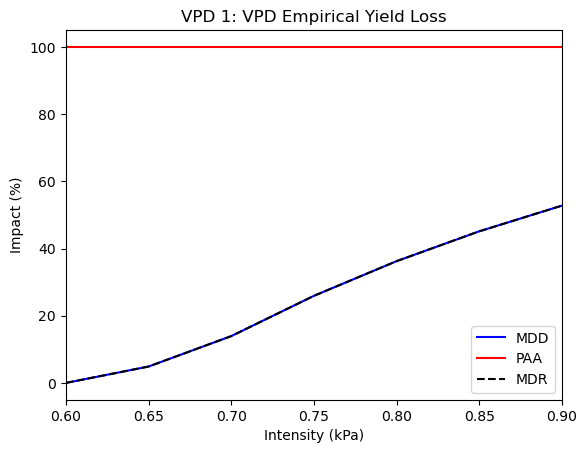

In [93]:
snap = Snapshot( exposure= exp_dict['present'],  # Exposure object for the present scenario
    hazard= haz_adjusted_dict['present'],  # Hazard object for the present scenario
    impfset=imp_fun_set_dict['present'],  # Impact function set
    date=2023  # Year of the snapshot
)

# We can fetch and plot the exposure, hazard and impact function from the snapshot
# snap.exposure.plot_raster()
# snap.hazard.plot_intensity(0)
snap.impfset.plot()

# Create a list to store the snapshots
snaps_list = []  # Store the snapshots in a list
# Store the present snapshot
snaps_list.append(snap)

Lets make the other snapshots

In [94]:
# Store the near future snapshot
snaps_list.append( Snapshot( exposure= exp_dict['near_future'],  # Exposure object for the near future scenario
                    hazard= haz_adjusted_dict['near_future'],  # Hazard object for the near future scenario
                    impfset=imp_fun_set_dict['near_future'],  # Impact function set
                    date=2040  # Year of the snapshot
                )
                )

# # Store the future snapshot
# snaps_list.append( Snapshot( exposure= exp_dict['future'],  # Exposure object for the future scenario
#                     hazard= haz_adjusted_dict['future'],  # Hazard object for the future scenario
#                     impfset=imp_fun_set_dict['future'],  # Impact function set
#                     date=2060  # Year of the snapshot
#                 )
#                 )

# 3 - Measures

The new measures class where we plant more agroforest trees

- 0-5 years
    - planting costs + maintenance
    - 0 % shading
    - 0 pos cash flows from fruits
- 6-10 years
    - maintenance
    - 50 % shading
    - 0 pos cash flows from fruits
- +10 years
    - maintenance
    - 100 % shading
    - some pos cash flows from fruits

we will make a measure that increase the minium amount of canopy to 70%


To accaunt for this weassume that the cooling effect of the max cool is 0%, 50% and 100%

In [106]:
# Define the canopy level for the measure
canopy_scenario = 50 # Minimum Canopy cover in percent


In [107]:
def make_hazard_mapper(canopy_scenario = 'current', exposure = exp_dict['present'], max_cooling_effect=1.0):
    # Use the present exposure for the mapper
    exp_col = apply_canopy_scenario(exposure, canopy_scenario=canopy_scenario) # or use a specific canopy cover value, e.g. 50
    # Define the adjustment function
    def haz_mapper(hazard, year=None): # The year parameter is not used in this example
        return adjust_hazard_with_exposure_modifier(
            exposure=exp_col,
            hazard=hazard,
            adjustment_fn=adjustment_fn,
            adjustment_kwargs={
                'max_cooling': 3.0 * max_cooling_effect, # Adjust the max cooling effect
                'plateau_at': 50,
                'vpd_sensitivity': 0.15
            }
        )
    return haz_mapper

In [108]:
from climada.engine.option_appraisal.appraiser import MeasuresAppraiser

# Define the measure
from climada.entity.measures.base import (
    Measure,
    helper_hazard,
    helper_impfset,
    helper_exposure,
)
from climada.entity.measures import MeasureSet
from climada.entity.measures.cost_income import CostIncome


# Measure 0-5 years (no effect)
meas_1 = Measure(
    haz_type="TC",
    name=f'Measure {canopy_scenario}_0-5',
    hazard_change= make_hazard_mapper(canopy_scenario = canopy_scenario, 
                                      exposure = exp_dict['present'], 
                                      max_cooling_effect=0.0  # No cooling effect for the first 5 years
                                      ),                                
    cost_income=CostIncome(
        mkt_price_year=2025,
        init_cost=-5_000_000_000, # Initial cost of the measure use function
        periodic_cost=1000,
        periodic_income=500,
        freq="AS-JAN",
    ),
)

# Measure 5-10 years (no effect)
meas_2 = Measure(
    haz_type="TC",
    name=f'Measure {canopy_scenario}_5-10',
    hazard_change= make_hazard_mapper(canopy_scenario = canopy_scenario, 
                                      exposure = exp_dict['present'], 
                                      max_cooling_effect=0.5,  # 50% cooling effect for the first 5 years
                                      ),                                
    cost_income=CostIncome(
        mkt_price_year=2025,
        init_cost=-0, # No initial cost of the measure
        periodic_cost=1000,
        periodic_income=500,
        freq="AS-JAN",
    ),
)

# Measure 5-10 years (no effect)
meas_3 = Measure(
    haz_type="TC",
    name=f'Measure {canopy_scenario}_+10',
    hazard_change= make_hazard_mapper(canopy_scenario = canopy_scenario, 
                                      exposure = exp_dict['present'], 
                                      max_cooling_effect=1.0,  # 50% cooling effect for the first 5 years
                                      ),                                
    cost_income=CostIncome(
        mkt_price_year=2025,
        init_cost=-0, # No initial cost of the measure
        periodic_cost=1000,
        periodic_income=500,
        freq="AS-JAN",
    ),
)

# gather all measures
meas_set = MeasureSet(measures=[meas_1, meas_2, meas_3])

# 4 - Measure apprasier 

In [109]:
from climada.entity.measures.base import (
    Measure,
    helper_hazard,
    helper_impfset,
    helper_exposure,
)

?helper_hazard

Signature: helper_hazard(intensity_multiplier=1, intensity_substract=0)
Docstring: <no docstring>
File:      ~/Documents/Programming/Climate/climada_python/climada/entity/measures/base.py
Type:      function

In [110]:
from climada.engine.option_appraisal.appraiser import MeasuresAppraiser, PlannedMeasuresAppraiser

In [111]:
?PlannedMeasuresAppraiser

Init signature:
PlannedMeasuresAppraiser(
    snapshots_list: list[climada.trajectories.snapshot.Snapshot],
    *,
    measure_set: climada.entity.measures.measure_set.MeasureSet,
    planner: dict[str, tuple[int, int]] | dict[str, tuple[datetime.date, datetime.date]],
    interval_freq: str = 'AS-JAN',
    all_groups_name: str = 'All',
    risk_disc: climada.entity.disc_rates.base.DiscRates | None = None,
    cost_disc: climada.entity.disc_rates.base.DiscRates | None = None,
    risk_transf_cover=None,
    risk_transf_attach=None,
    calc_residual: bool = True,
    interpolation_strategy: climada.trajectories.interpolation.InterpolationStrategy | None = None,
    impact_computation_strategy: climada.trajectories.impact_calc_strat.ImpactComputationStrategy | None = None,
)
Docstring:     
Calculates risk trajectories over a series of snapshots.

This class computes risk metrics over a series of snapshots,
optionally applying risk discounting and risk transfer adjustments.

Attributes


Make planner to account for the benefits

In [112]:

# Define the appraiser when the meaures are active
start_year = 2025  # Year when the measures start
planner = {f'Measure {canopy_scenario}_0-5': (start_year, start_year + 5),
           f'Measure {canopy_scenario}_5-10': (start_year + 6, start_year + 10), 
           f'Measure {canopy_scenario}_+10': (start_year + 11, start_year + 40)}

# Create the appraiser for the planned measures
planned = PlannedMeasuresAppraiser(snaps_list, measure_set=meas_set, planner=planner)

100%|██████████| 90/90 [00:00<00:00, 1022.24it/s]


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

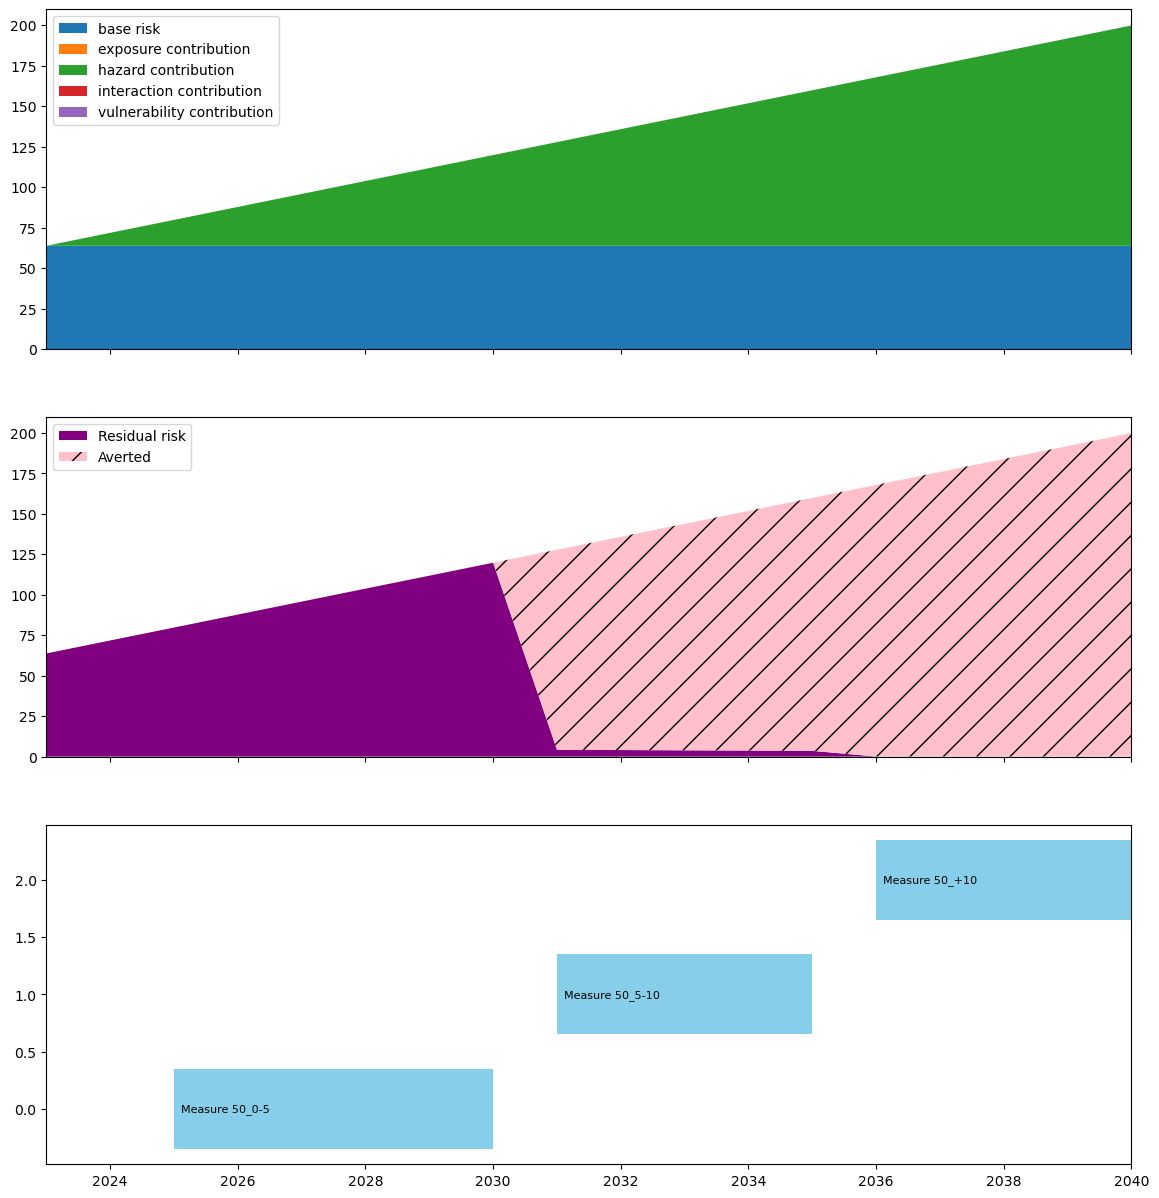

In [113]:
planned.plot_per_date_waterfall_CB()

In [114]:
planned.aai_metrics()

100%|██████████| 18/18 [00:00<00:00, 403.04it/s]


,measure,date,group,metric,risk,reference risk,averted risk,measure net cost,measure cost benefit
16,no_measure,2023-01-01,All,aai,63.732601,63.732601,0.000000,0.000000e+00,0.000000e+00
17,no_measure,2024-01-01,All,aai,71.739244,71.739244,0.000000,0.000000e+00,0.000000e+00
5,Measure 50_0-5,2025-01-01,All,aai,79.745887,79.745887,0.000000,5.000000e+09,-5.000000e+09
6,Measure 50_0-5,2026-01-01,All,aai,87.752530,87.752530,0.000000,5.000000e+02,-5.000000e+02
7,Measure 50_0-5,2027-01-01,All,aai,95.759174,95.759174,0.000000,5.000000e+02,-5.000000e+02
8,Measure 50_0-5,2028-01-01,All,aai,103.765817,103.765817,0.000000,5.000000e+02,-5.000000e+02
9,Measure 50_0-5,2029-01-01,All,aai,111.772460,111.772460,0.000000,5.000000e+02,-5.000000e+02
10,Measure 50_0-5,2030-01-01,All,aai,119.779103,119.779103,0.000000,5.000000e+02,-5.000000e+02
11,Measure 50_5-10,2031-01-01,All,aai,4.233093,127.785747,123.552653,-5.000000e+02,6.235527e+02
12,Measure 50_5-10,2032-01-01,All,aai,4.068771,135.792390,131.723619,5.000000e+02,-3.682764e+02
